# 🏠 Indoor Positioning using Wi-Fi & Bluetooth Fingerprinting

## What does this project do?

Imagine you're inside a large building — a hospital, shopping mall, or office — and GPS doesn't work indoors. How does your phone know which room you're in?

**This project solves that problem.** It uses the Wi-Fi and Bluetooth signals that are already floating around in every building to figure out your exact location inside a room.

### How it works (in simple terms):

1. **Signal Fingerprinting**: Every spot in a room receives a slightly different mix of Wi-Fi and Bluetooth signal strengths. We measure these signal strengths (called RSSI — Received Signal Strength Indicator) at many known locations to create a "fingerprint database."

2. **Machine Learning**: We train three different AI models (KNN, SVM, Random Forest) to learn the patterns in these fingerprints. When a new signal reading comes in, the models predict which location it most likely came from.

3. **Comparison**: We compare how well the system works with **Wi-Fi signals alone** vs. **Wi-Fi + Bluetooth signals combined**. The key question is: *does adding Bluetooth data reduce localization error?*

### Dataset

We use the [RSSI Dataset for Indoor Localization Fingerprinting](https://github.com/pspachos/RSSI-Dataset-for-Indoor-Localization-Fingerprinting) collected across three real indoor scenarios with Raspberry Pi devices and Bluetooth beacons.

---
## Step 0: Setup

First, we import all the helper functions we've written. These handle the heavy lifting — downloading data, training models, and making plots — so this notebook stays clean and easy to follow.

In [41]:
# Add the project root to the Python path so we can import our modules
import sys
import os

# Go up one level from notebooks/ to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import our custom helper modules
from functions.load_data import get_clean_data, load_scenario_data, RSSI_COLUMNS
from functions.fusion import prepare_both_datasets
from functions.models import run_full_evaluation, compare_results
from functions.plots import plot_all_confusion_matrices, plot_accuracy_comparison, plot_error_comparison

# Standard libraries for display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Show plots inline in the notebook
%matplotlib inline

# Set output directory for saved plots
OUTPUT_DIR = os.path.join(project_root, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ All modules loaded successfully!')
print(f'📁 Plots will be saved to: {OUTPUT_DIR}')

✅ All modules loaded successfully!
📁 Plots will be saved to: c:\Users\daksh\Desktop\Daksh\MAJOR PROJECT\code\indoor-positioning\outputs


---
## Step 1: Load and Inspect the Raw Data

Let's download the dataset directly from GitHub and see what it looks like.

The dataset was collected in a meeting room (Scenario 1) with **three wireless transmitters** placed in a triangle formation. Researchers walked around the room measuring signal strength at 49 different spots — these become our "fingerprint database." Then 10 random test points were selected to see how well we can predict location.

Each data point has:
- **x, y** — the physical coordinates (in meters) where the reading was taken
- **RSSI A, RSSI B, RSSI C** — signal strength from each of the three transmitters (higher = stronger signal)

In [42]:
# Download WiFi data for Scenario 1 from GitHub
# This fetches the xlsx file, reads the 'WiFi' sheet, and creates location labels
wifi_db_raw, wifi_test_raw = load_scenario_data(scenario=1, technology='WiFi')

print('\n📋 WiFi Database (first 10 fingerprint points):')
print(f'   Total points: {len(wifi_db_raw)}')
wifi_db_raw.head(10)

  ↳ Downloading Database_Scenario1.xlsx …
  ↳ Downloading Tests_Scenario1.xlsx …

📋 WiFi Database (first 10 fingerprint points):
   Total points: 49


,x,y,RSSI A,RSSI B,RSSI C,location
0,0.5,0.5,44,56,44,P_0.5_0.5
1,0.5,1.0,43,52,56,P_0.5_1.0
2,0.5,1.5,51,51,55,P_0.5_1.5
3,0.5,2.0,48,51,59,P_0.5_2.0
4,0.5,2.5,55,59,60,P_0.5_2.5
5,0.5,3.0,49,40,58,P_0.5_3.0
6,0.5,3.5,57,50,64,P_0.5_3.5
7,1.0,0.5,43,49,51,P_1.0_0.5
8,1.0,1.0,48,56,51,P_1.0_1.0
9,1.0,1.5,52,48,61,P_1.0_1.5


In [43]:
# Let's also look at the WiFi test points
print('📋 WiFi Test Points (these are the locations we want to predict):')
print(f'   Total test points: {len(wifi_test_raw)}')
wifi_test_raw

📋 WiFi Test Points (these are the locations we want to predict):
   Total test points: 10


,x,y,RSSI A,RSSI B,RSSI C,location
0,1.00,0.00,34,56,57,P_1.0_0.0
1,0.00,3.00,53,55,49,P_0.0_3.0
2,3.25,1.25,56,40,59,P_3.25_1.25
3,0.75,1.25,55,61,51,P_0.75_1.25
4,2.50,2.00,53,54,53,P_2.5_2.0
5,1.50,2.50,57,51,41,P_1.5_2.5
6,2.25,3.50,59,52,53,P_2.25_3.5
7,0.50,3.25,53,53,47,P_0.5_3.25
8,3.50,2.25,54,58,55,P_3.5_2.25
9,0.25,0.25,47,57,55,P_0.25_0.25


In [44]:
# Now let's look at the BLE (Bluetooth) data for comparison
ble_db_raw, ble_test_raw = load_scenario_data(scenario=1, technology='BLE')

print('📋 BLE Database (first 10 fingerprint points):')
print(f'   Total points: {len(ble_db_raw)}')
ble_db_raw.head(10)

  ↳ Downloading Database_Scenario1.xlsx …
  ↳ Downloading Tests_Scenario1.xlsx …
📋 BLE Database (first 10 fingerprint points):
   Total points: 49


,x,y,RSSI A,RSSI B,RSSI C,location
0,0.5,0.5,75,93,87,P_0.5_0.5
1,0.5,1.0,70,88,85,P_0.5_1.0
2,0.5,1.5,83,81,85,P_0.5_1.5
3,0.5,2.0,86,84,87,P_0.5_2.0
4,0.5,2.5,79,81,82,P_0.5_2.5
5,0.5,3.0,80,76,93,P_0.5_3.0
6,0.5,3.5,83,68,93,P_0.5_3.5
7,1.0,0.5,83,84,83,P_1.0_0.5
8,1.0,1.0,76,87,85,P_1.0_1.0
9,1.0,1.5,80,88,76,P_1.0_1.5


### 🔍 Key Observations

Notice how:
- **WiFi RSSI values** are typically in the range of 30-70
- **BLE RSSI values** are typically in the range of 60-95
- Both datasets share the same (x, y) coordinates — they were measured at the same spots!
- The **location** column is a label we created from the coordinates (e.g., "P_0.5_0.5" means position at x=0.5m, y=0.5m)

---
## Step 2: Prepare the Datasets

Now we prepare two versions of the data for our machine learning models:

1. **WiFi-Only**: Uses just the 3 WiFi signal strengths as features
2. **WiFi + BLE Fused**: Combines WiFi and BLE signals into 6 features per location

The preparation includes:
- Replacing any missing signal readings with -100 (meaning "no signal detected")
- **Normalizing** the RSSI values to a 0-1 range so all features are on the same scale
- Converting location names to numbers (required by the ML models)

In [45]:
# This function does everything: downloads WiFi + BLE data, preprocesses both,
# and returns two ready-to-use datasets
wifi_data, fused_data = prepare_both_datasets(scenario=1)

print('\n' + '='*50)
print('📊 Dataset Summary')
print('='*50)
print(f'\nWiFi-Only:')
print(f'  Features: {wifi_data["features"]}')
print(f'  Training samples: {len(wifi_data["db"])}')
print(f'  Test samples: {len(wifi_data["test"])}')

print(f'\nWiFi+BLE Fused:')
print(f'  Features: {fused_data["features"]}')
print(f'  Training samples: {len(fused_data["db"])}')
print(f'  Test samples: {len(fused_data["test"])}')


📡 Loading Wi-Fi data for Scenario 1…
  ↳ Downloading Database_Scenario1.xlsx …
  ↳ Downloading Tests_Scenario1.xlsx …
  ✓ WiFi — Database: 49 | Tests: 10

📡 Loading BLE data for Scenario 1…
  ↳ Downloading Database_Scenario1.xlsx …
  ↳ Downloading Tests_Scenario1.xlsx …
  ✓ BLE  — Database: 49 | Tests: 10

🔧 Preparing Wi-Fi-only dataset…

🔧 Preparing Fused (WiFi + BLE) dataset…
  ✓ Fused database: 49 points × 9 cols
  ✓ Fused tests:    10 points × 9 cols

📊 Dataset Summary

WiFi-Only:
  Features: ['RSSI A', 'RSSI B', 'RSSI C']
  Training samples: 49
  Test samples: 10

WiFi+BLE Fused:
  Features: ['WiFi_RSSI_A', 'WiFi_RSSI_B', 'WiFi_RSSI_C', 'BLE_RSSI_A', 'BLE_RSSI_B', 'BLE_RSSI_C']
  Training samples: 49
  Test samples: 10


In [46]:
# Let's peek at what the preprocessed fused data looks like
# Notice all RSSI values are now between 0 and 1 (normalized)
print('📋 Fused dataset (first 5 rows — normalized values):')
fused_data['db'][fused_data['features'] + ['location', 'label']].head()

📋 Fused dataset (first 5 rows — normalized values):


,WiFi_RSSI_A,WiFi_RSSI_B,WiFi_RSSI_C,BLE_RSSI_A,BLE_RSSI_B,BLE_RSSI_C,location,label
0,0.043478,0.842105,0.259259,0.20,0.925926,0.65,P_0.5_0.5,2
1,0.000000,0.631579,0.703704,0.00,0.740741,0.55,P_0.5_1.0,3
2,0.347826,0.578947,0.666667,0.52,0.481481,0.55,P_0.5_1.5,4
3,0.217391,0.578947,0.814815,0.64,0.592593,0.65,P_0.5_2.0,5
4,0.521739,1.000000,0.851852,0.36,0.481481,0.40,P_0.5_2.5,6


---
## Step 3: Train Machine Learning Models

We train three different classifiers on each dataset. Each one uses a different strategy to predict location:

| Model | How it works (simple explanation) |
|-------|----------------------------------|
| **KNN** (K-Nearest Neighbors) | Looks at the 3 most similar fingerprints in the database and picks the most common location among them. Like asking "which known spots have the most similar signals?" |
| **SVM** (Support Vector Machine) | Draws boundaries between different locations in the signal space. Like drawing lines on a map to separate regions. |
| **Random Forest** | Uses 100 decision trees that each vote on the location. The majority vote wins. Like asking 100 experts and going with the consensus. |

We run each model on **both** WiFi-only and Fused data to see which combination works best.

If each location is unique (one sample per class), we automatically switch to coordinate regression and report mean distance error (meters).

In [47]:
# Train and evaluate all 3 models on the WiFi-only dataset
wifi_eval = run_full_evaluation(wifi_data, dataset_name='WiFi-Only')


  📊 Evaluating: WiFi-Only
  Training set: 49 samples, 3 features
  Test set:     10 samples
  Task type:    regression

  🏋️ Training KNN…
    ✓ KNN mean error: 1.784 m

  🏋️ Training SVR…
    ✓ SVR mean error: 2.107 m

  🏋️ Training Random Forest…
    ✓ Random Forest mean error: 1.700 m


In [48]:
# Train and evaluate all 3 models on the WiFi+BLE fused dataset
fused_eval = run_full_evaluation(fused_data, dataset_name='WiFi+BLE Fused')

task_type = wifi_eval['task']
if task_type != fused_eval['task']:
    raise ValueError('WiFi and Fused evaluations returned different task types.')

wifi_results = wifi_eval['results']
fused_results = fused_eval['results']

print(f'✅ Task type: {task_type}')


  📊 Evaluating: WiFi+BLE Fused
  Training set: 49 samples, 6 features
  Test set:     10 samples
  Task type:    regression

  🏋️ Training KNN…
    ✓ KNN mean error: 1.506 m

  🏋️ Training SVR…
    ✓ SVR mean error: 1.846 m

  🏋️ Training Random Forest…
    ✓ Random Forest mean error: 1.670 m
✅ Task type: regression


---
## Step 4: Compare Results

Let's see the performance numbers side by side. This dataset is evaluated as coordinate regression, so the main metric is mean distance error in meters. Lower values are better.

In [49]:
# Create a clean comparison table
comparison_df = compare_results(wifi_eval, fused_eval)

# Format numbers nicely based on task type
if task_type == 'classification':
    styled = comparison_df.style.format({
        'WiFi-Only Accuracy': '{:.1%}',
        'WiFi+BLE Fused Accuracy': '{:.1%}',
        'Improvement': '{:+.1%}',
    }).set_caption('Classification Accuracy Comparison: WiFi-Only vs WiFi+BLE Fused')
else:
    styled = comparison_df.style.format({
        'WiFi Mean Error (m)': '{:.2f}',
        'Fused Mean Error (m)': '{:.2f}',
        'Improvement (m)': '{:+.2f}',
    }).set_caption('Mean Distance Error: WiFi-Only vs WiFi+BLE Fused')

styled

,Model,WiFi Mean Error (m),Fused Mean Error (m),Improvement (m)
0,KNN,1.78,1.51,+0.28
1,SVR,2.11,1.85,+0.26
2,Random Forest,1.70,1.67,+0.03


---
## Step 5: Visualize the Results

### 5a. Performance Comparison Bar Chart

This chart gives us a quick visual comparison of how each model performs with WiFi-only vs. the fused approach.

  💾 Saved: c:\Users\daksh\Desktop\Daksh\MAJOR PROJECT\code\indoor-positioning\outputs\error_comparison.png


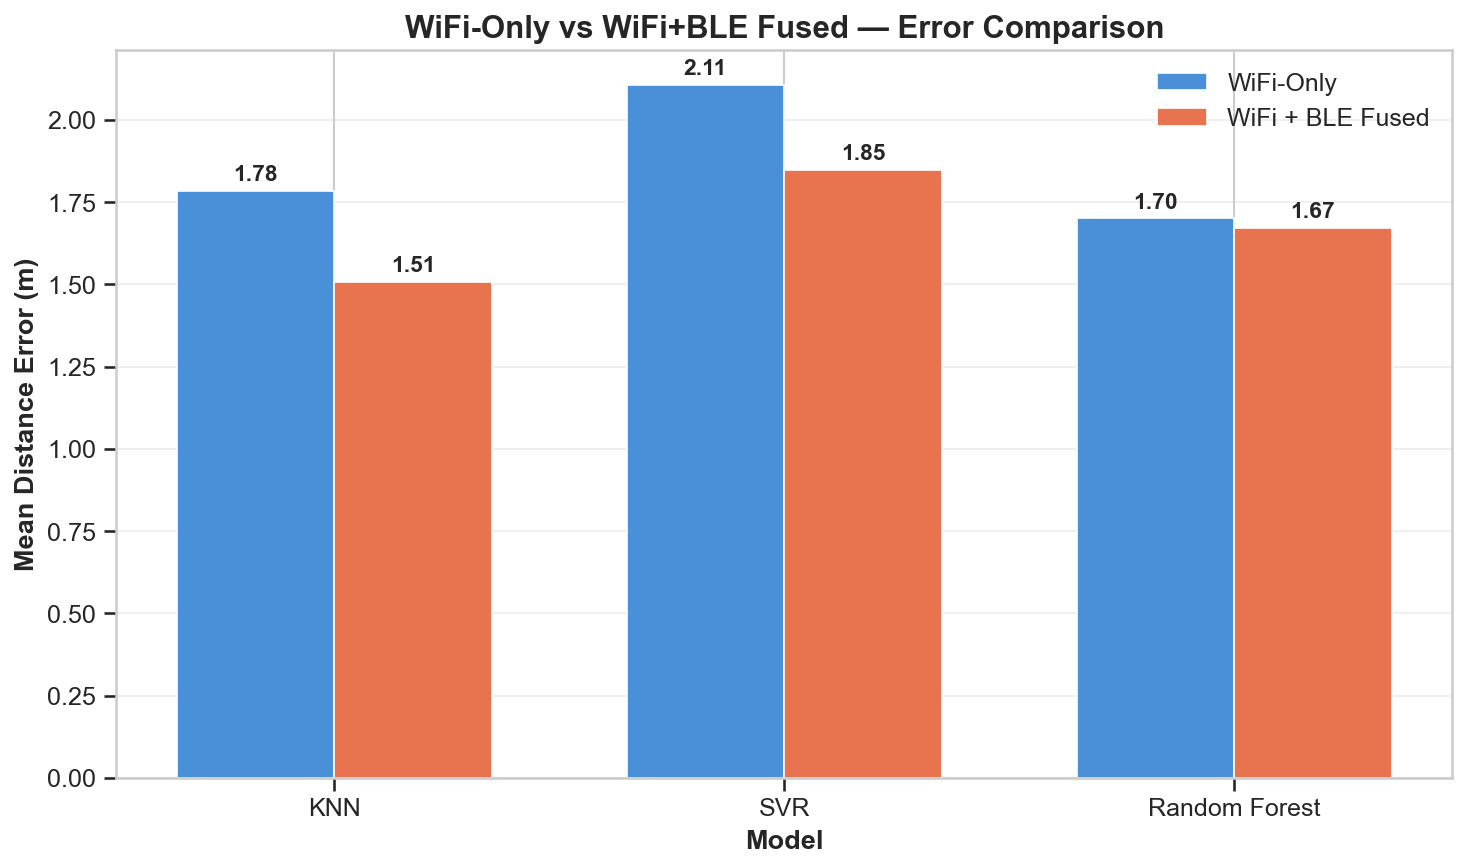

In [50]:
# Plot the performance comparison bar chart
if task_type == 'classification':
    acc_path = plot_accuracy_comparison(wifi_results, fused_results, output_dir=OUTPUT_DIR)
    from IPython.display import Image, display
    display(Image(filename=acc_path))
else:
    err_path = plot_error_comparison(wifi_results, fused_results, output_dir=OUTPUT_DIR)
    from IPython.display import Image, display
    display(Image(filename=err_path))

### 5b. Confusion Matrices — WiFi-Only (classification only)

A **confusion matrix** shows exactly which locations the model got right and which ones it confused. 

- Each row = the **actual** location of a test point
- Each column = the location the model **predicted**
- Numbers on the **diagonal** (top-left to bottom-right) = correct predictions ✅
- Numbers **off the diagonal** = mistakes ❌

Darker blue = higher count.

In [51]:
# Plot confusion matrices for WiFi-only results (classification only)
if task_type == 'classification':
    wifi_cm_paths = plot_all_confusion_matrices(
        wifi_results, 
        dataset_name='WiFi-Only', 
        output_dir=OUTPUT_DIR,
        encoder=wifi_data['encoder']
    )

    # Show inline
    for path in wifi_cm_paths:
        display(Image(filename=path))
else:
    print('Skipping confusion matrices (regression task).')

Skipping confusion matrices (regression task).


### 5c. Confusion Matrices — WiFi + BLE Fused (classification only)

Now let's see the confusion matrices for the fused approach. Compare these with the WiFi-only ones above — you should notice fewer mistakes (more values on the diagonal).

In [52]:
# Plot confusion matrices for fused results (classification only)
if task_type == 'classification':
    fused_cm_paths = plot_all_confusion_matrices(
        fused_results, 
        dataset_name='WiFi+BLE Fused', 
        output_dir=OUTPUT_DIR,
        encoder=fused_data['encoder']
    )

    # Show inline
    for path in fused_cm_paths:
        display(Image(filename=path))
else:
    print('Skipping confusion matrices (regression task).')

Skipping confusion matrices (regression task).


---
## Summary & Conclusions

### What we did:

1. **Downloaded** real-world RSSI (signal strength) data from the RSSI Dataset for Indoor Localization Fingerprinting

2. **Created two datasets**:
   - **WiFi-Only**: 3 features (signal strength from 3 WiFi transmitters)
   - **WiFi+BLE Fused**: 6 features (3 WiFi + 3 Bluetooth signal strengths)

3. **Trained 3 ML models** (KNN, SVR, Random Forest) on both datasets

4. **Compared localization performance** using mean distance error in meters. Lower error means the predicted position is closer to the actual test point.

### Key findings:

- For the evaluated demo scenarios, **WiFi+BLE fusion reduces mean localization error** compared with WiFi-only positioning.

- The dataset uses a small number of reference and test points, so results should be interpreted as a controlled prototype rather than a production deployment.

- **KNN** is a strong baseline for fingerprint-based positioning because it directly compares signal fingerprints by distance.

- **Random Forest** is useful as a robust ensemble model, while **SVR** provides a nonlinear regression baseline for coordinate prediction.

### Real-world applications:

- **Hospitals**: Track equipment and staff across floors

- **Shopping malls**: Guide customers to stores with turn-by-turn indoor navigation

- **Factories (Industry 5.0)**: Monitor worker locations for safety and efficiency

- **Smart offices**: Automate room booking and HVAC based on occupancy


In [53]:
# Final summary table
print('\n' + '='*60)
print('  🏆 FINAL RESULTS SUMMARY')
print('='*60)
print(comparison_df.to_string(index=False))
print('\n✅ All plots saved to the outputs/ folder.')
print('📂 Check the outputs/ directory for high-resolution images.')


  🏆 FINAL RESULTS SUMMARY
        Model  WiFi Mean Error (m)  Fused Mean Error (m)  Improvement (m)
          KNN             1.783551              1.506288         0.277263
          SVR             2.106684              1.845895         0.260789
Random Forest             1.699741              1.670225         0.029516

✅ All plots saved to the outputs/ folder.
📂 Check the outputs/ directory for high-resolution images.


---
## Compare All Scenarios

Run this optional section when you want to see Scenario 1 and Scenario 2 side by side. Each scenario saves its plot into a separate folder under `outputs/` so the images do not overwrite each other.



SCENARIO 1

📡 Loading Wi-Fi data for Scenario 1…
  ↳ Downloading Database_Scenario1.xlsx …
  ↳ Downloading Tests_Scenario1.xlsx …
  ✓ WiFi — Database: 49 | Tests: 10

📡 Loading BLE data for Scenario 1…
  ↳ Downloading Database_Scenario1.xlsx …
  ↳ Downloading Tests_Scenario1.xlsx …
  ✓ BLE  — Database: 49 | Tests: 10

🔧 Preparing Wi-Fi-only dataset…

🔧 Preparing Fused (WiFi + BLE) dataset…
  ✓ Fused database: 49 points × 9 cols
  ✓ Fused tests:    10 points × 9 cols

  📊 Evaluating: Scenario 1 WiFi-Only
  Training set: 49 samples, 3 features
  Test set:     10 samples
  Task type:    regression

  🏋️ Training KNN…
    ✓ KNN mean error: 1.784 m

  🏋️ Training SVR…
    ✓ SVR mean error: 2.107 m

  🏋️ Training Random Forest…
    ✓ Random Forest mean error: 1.700 m

  📊 Evaluating: Scenario 1 WiFi+BLE Fused
  Training set: 49 samples, 6 features
  Test set:     10 samples
  Task type:    regression

  🏋️ Training KNN…
    ✓ KNN mean error: 1.506 m

  🏋️ Training SVR…
    ✓ SVR mean error:

,Model,WiFi Mean Error (m),Fused Mean Error (m),Improvement (m)
0,KNN,1.783551,1.506288,0.277263
1,SVR,2.106684,1.845895,0.260789
2,Random Forest,1.699741,1.670225,0.029516


  💾 Saved: c:\Users\daksh\Desktop\Daksh\MAJOR PROJECT\code\indoor-positioning\outputs\scenario_1\error_comparison.png


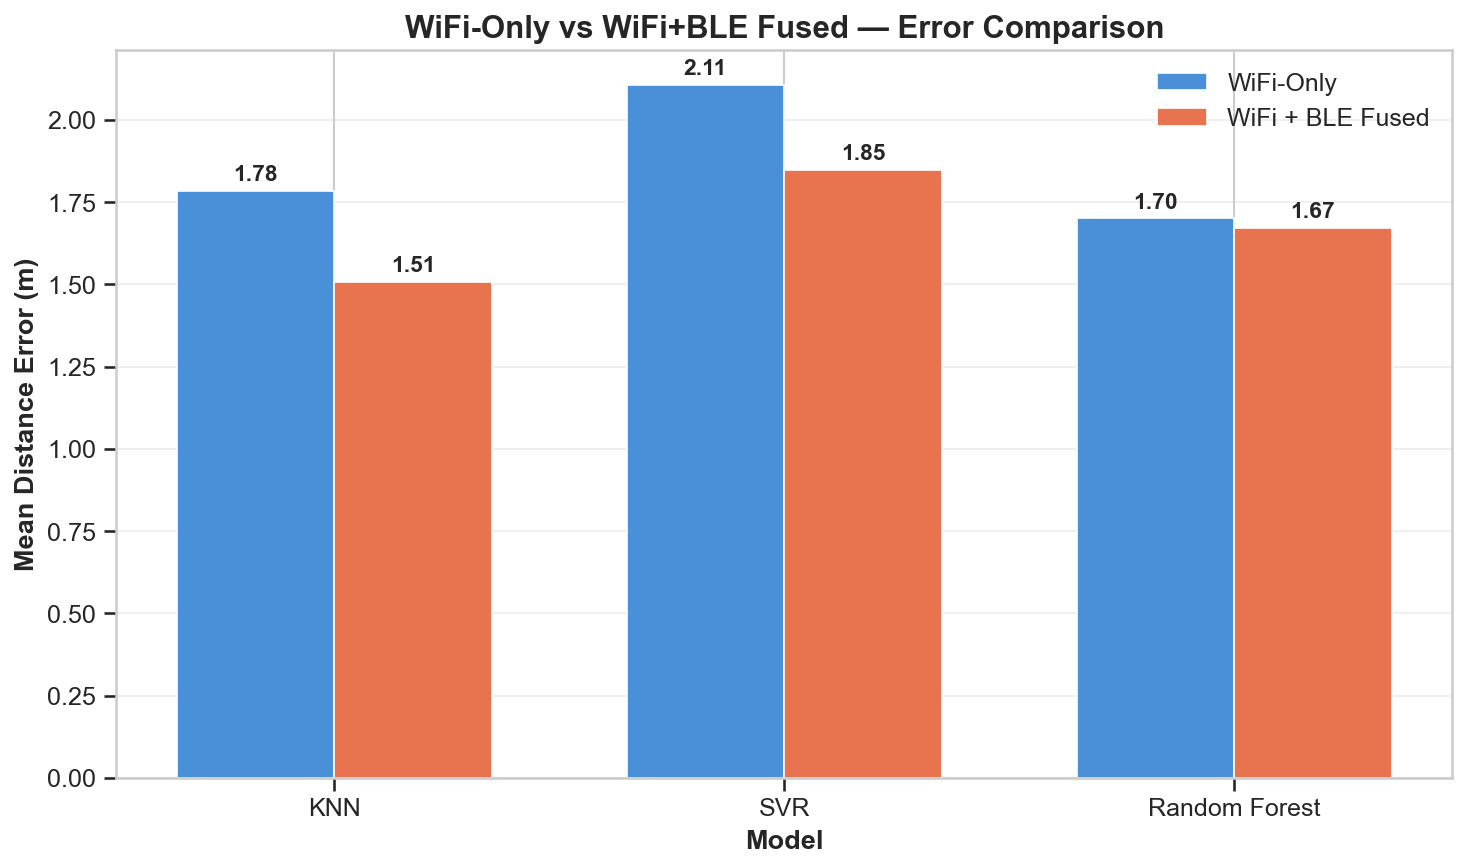


SCENARIO 2

📡 Loading Wi-Fi data for Scenario 2…
  ↳ Downloading Database_Scenario2.xlsx …
  ↳ Downloading Tests_Scenario2.xlsx …
  ✓ WiFi — Database: 16 | Tests: 6

📡 Loading BLE data for Scenario 2…
  ↳ Downloading Database_Scenario2.xlsx …
  ↳ Downloading Tests_Scenario2.xlsx …
  ✓ BLE  — Database: 16 | Tests: 6

🔧 Preparing Wi-Fi-only dataset…

🔧 Preparing Fused (WiFi + BLE) dataset…
  ✓ Fused database: 16 points × 9 cols
  ✓ Fused tests:    6 points × 9 cols

  📊 Evaluating: Scenario 2 WiFi-Only
  Training set: 16 samples, 3 features
  Test set:     6 samples
  Task type:    regression

  🏋️ Training KNN…
    ✓ KNN mean error: 1.900 m

  🏋️ Training SVR…
    ✓ SVR mean error: 2.203 m

  🏋️ Training Random Forest…
    ✓ Random Forest mean error: 1.743 m

  📊 Evaluating: Scenario 2 WiFi+BLE Fused
  Training set: 16 samples, 6 features
  Test set:     6 samples
  Task type:    regression

  🏋️ Training KNN…
    ✓ KNN mean error: 1.573 m

  🏋️ Training SVR…
    ✓ SVR mean error: 1.72

,Model,WiFi Mean Error (m),Fused Mean Error (m),Improvement (m)
0,KNN,1.899782,1.572946,0.326836
1,SVR,2.203131,1.725516,0.477615
2,Random Forest,1.743307,1.626587,0.116720


  💾 Saved: c:\Users\daksh\Desktop\Daksh\MAJOR PROJECT\code\indoor-positioning\outputs\scenario_2\error_comparison.png


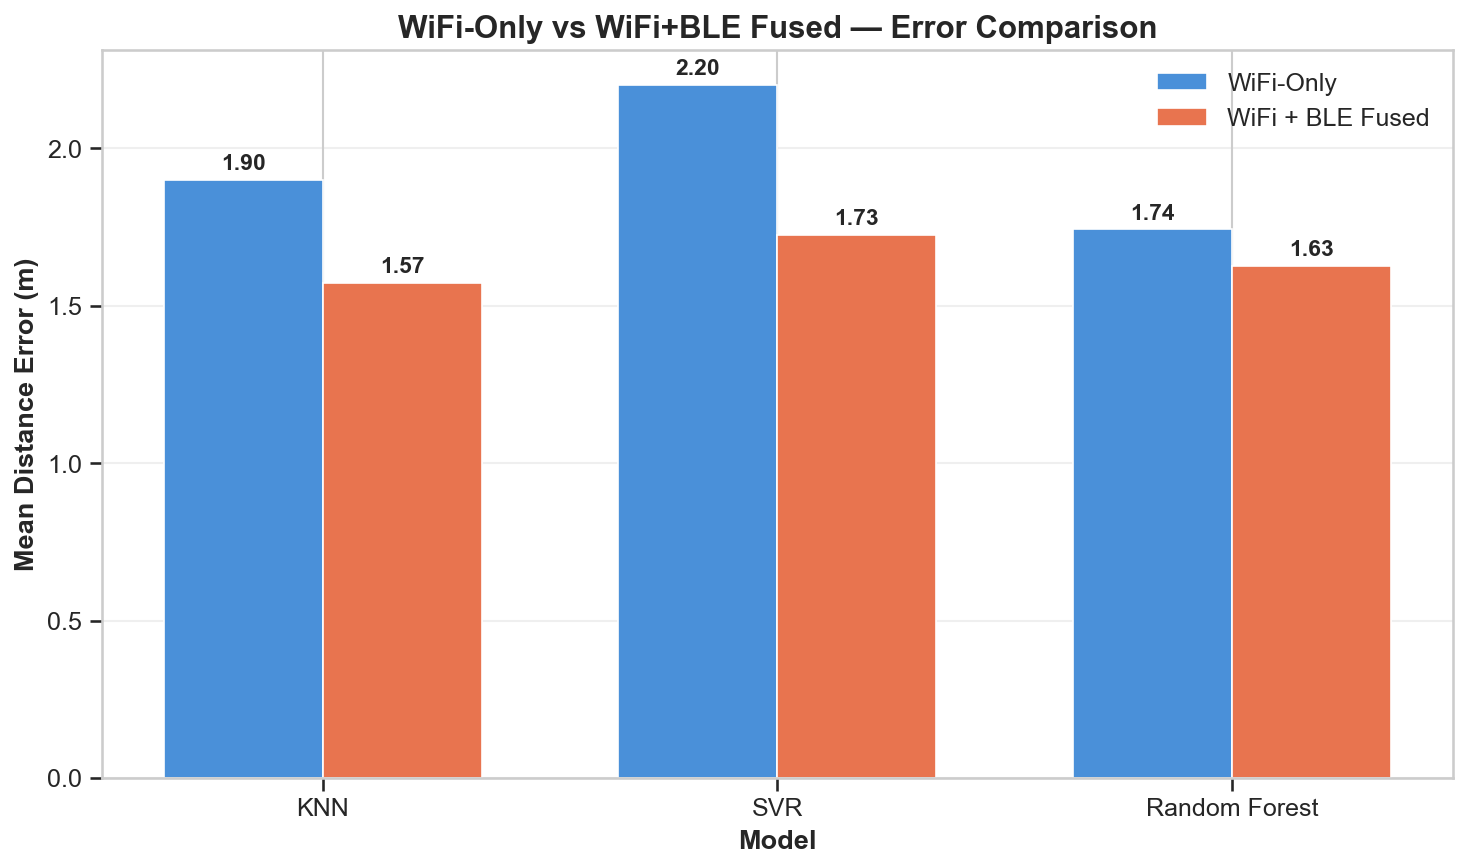

In [54]:
# Optional: run all scenarios and compare WiFi-only vs WiFi+BLE fused results
from IPython.display import Image, display

all_scenario_results = {}

for scenario in [1, 2]:
    print('\n' + '=' * 70)
    print(f'SCENARIO {scenario}')
    print('=' * 70)

    scenario_output_dir = os.path.join(OUTPUT_DIR, f"scenario_{scenario}")
    os.makedirs(scenario_output_dir, exist_ok=True)

    scenario_wifi_data, scenario_fused_data = prepare_both_datasets(scenario=scenario)

    scenario_wifi_eval = run_full_evaluation(
        scenario_wifi_data,
        dataset_name=f"Scenario {scenario} WiFi-Only",
    )
    scenario_fused_eval = run_full_evaluation(
        scenario_fused_data,
        dataset_name=f"Scenario {scenario} WiFi+BLE Fused",
    )

    scenario_comparison_df = compare_results(scenario_wifi_eval, scenario_fused_eval)
    display(scenario_comparison_df)

    if scenario_wifi_eval["task"] == "classification":
        plot_path = plot_accuracy_comparison(
            scenario_wifi_eval["results"],
            scenario_fused_eval["results"],
            output_dir=scenario_output_dir,
        )
    else:
        plot_path = plot_error_comparison(
            scenario_wifi_eval["results"],
            scenario_fused_eval["results"],
            output_dir=scenario_output_dir,
        )

    display(Image(filename=plot_path))

    all_scenario_results[scenario] = {
        "wifi_eval": scenario_wifi_eval,
        "fused_eval": scenario_fused_eval,
        "comparison": scenario_comparison_df,
        "plot_path": plot_path,
    }
